# Week 10 — Recommendation, Ranking, or Predictive Decision Engine

Este notebook corresponde a la **parte 10** del proyecto y se construye **a partir del K-means ya trabajado en `clustering.ipynb`**.

La idea principal no es volver a justificar el clustering desde cero, sino usar el resultado de K-means como una señal para un sistema de recomendación/ranking.

Estructura usada:

- **10.2 Baseline system**
- **10.3 Stronger system**
- **10.4 Offline evaluation report**
- **10.5 Error analysis**
- **10.6 Explanation of system type**
- **10.7 Technical expectation**

> Nota: el setup inicial reconstruye el mismo flujo técnico del notebook de clustering: features → PCA con 10 componentes → K-means con K=5. Esto permite que Week 10 use el espacio PCA y los clusters como señales del sistema de ranking.

## Setup previo — cargar datos y reconstruir PCA + K-means

Esta sección no reemplaza el análisis de clustering de Week 7. Solo deja listo el dataset para Week 10 usando la misma lógica técnica: primero se construyen las features, luego se reduce dimensionalidad con PCA y recién después se aplica K-means.

Se usa la misma base limpia:

```text
../data/processed/repos_clean.csv
```

Y se reconstruyen las features usadas anteriormente:

- variables numéricas;
- lenguaje principal;
- topics principales;
- PCA con 10 componentes, usado como espacio de representación para clustering y ranking;
- K-means con K=5 aplicado sobre el espacio PCA;
- nombres interpretables de clusters.

In [1]:
# ============================================================
# Setup de librerías y rutas
# ============================================================

import ast
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MultiLabelBinarizer, normalize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


def find_project_root() -> Path:
    # Busca la raíz del proyecto a partir de la ubicación actual del notebook.
    current = Path.cwd().resolve()
    candidates = [current] + list(current.parents)
    for candidate in candidates:
        expected_file = candidate / "data" / "processed" / "repos_clean.csv"
        if expected_file.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró data/processed/repos_clean.csv. "
        "Ejecuta este notebook dentro del proyecto BD-PROJECT o revisa la ruta del dataset."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "repos_clean.csv"
REPORT_DIR = PROJECT_ROOT / "reports" / "W10"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "W10"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Reportes W10:", REPORT_DIR)
print("Artefactos W10:", ARTIFACT_DIR)

Raíz del proyecto: C:\Users\HP\Desktop\Big-data\bd-project\notebooks
Dataset: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\data\processed\repos_clean.csv
Reportes W10: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\reports\W10
Artefactos W10: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10


In [2]:
# ============================================================
# Cargar dataset limpio
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {df.shape}")
print("Columnas disponibles:")
print(df.columns.tolist())

required_columns = [
    "repo_id", "nombre", "descripcion", "lenguaje", "stars", "forks", "topics",
    "dias_sin_commit", "antiguedad_dias", "num_topics", "ratio_forks_stars", "stars_por_dia"
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas necesarias para Week 10: {missing_columns}")

display(df.head(3))

Dataset cargado: (3034, 17)
Columnas disponibles:
['repo_id', 'nombre', 'descripcion', 'lenguaje', 'stars', 'forks', 'topics', 'fecha_creacion', 'ultimo_commit', 'url', 'dias_sin_commit', 'antiguedad_dias', 'num_topics', 'ratio_forks_stars', 'stars_por_dia', 'pca_x', 'pca_y']


,repo_id,nombre,descripcion,lenguaje,stars,forks,topics,fecha_creacion,ultimo_commit,url,dias_sin_commit,antiguedad_dias,num_topics,ratio_forks_stars,stars_por_dia,pca_x,pca_y
0,45717250,tensorflow/tensorflow,An Open Source Machine Learning Framework for Everyone,C++,194936,75296,"['tensorflow', 'machine-learning', 'python', 'deep-learning', 'deep-neural-networks', 'neural-network', 'ml', 'distr...",2015-11-07 01:19:20+00:00,2026-04-30 04:02:39+00:00,https://github.com/tensorflow/tensorflow,0,3827,8,0.3863,50.9370,-0.086113,-0.304143
1,574523116,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discover, and collect prompts from the community. Free and open source — self...",HTML,161175,21050,"['chatgpt', 'ai', 'artificial-intelligence', 'awesome-list', 'chatgpt-prompts', 'claude', 'gemini', 'gpt', 'gpt-4', ...",2022-12-05 13:54:13+00:00,2026-04-29 04:17:20+00:00,https://github.com/f/prompts.chat,1,1241,18,0.1306,129.8751,-0.230721,0.213816
2,155220641,huggingface/transformers,"🤗 Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, ...",Python,160100,33058,"['nlp', 'natural-language-processing', 'pytorch', 'pytorch-transformers', 'transformer', 'model-hub', 'pretrained-mo...",2018-10-29 13:56:00+00:00,2026-04-30 03:10:53+00:00,https://github.com/huggingface/transformers,0,2739,19,0.2065,58.4520,0.117394,-0.047015


In [3]:
# ============================================================
# Preparación de tipos y estructura para Week 10
# ============================================================

# El dataset ya está limpio. Esta celda no modifica la calidad del dato;
# solo prepara formatos necesarios para que este notebook aparte pueda calcular
# similitudes, PCA, K-means y rankings de forma independiente.
#
# Al leer desde CSV, la columna topics suele llegar como texto:
# "['tensorflow', 'machine-learning', 'python']"
# Por eso la convertimos a una lista real de Python para poder operar con ella.
def parse_topics(value):
    if isinstance(value, list):
        return [str(t).strip().lower() for t in value if str(t).strip()]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if value in ["", "[]", "nan", "None"]:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(t).strip().lower() for t in parsed if str(t).strip()]
        except Exception:
            # Respaldo por si algún registro viniera separado por comas.
            return [t.strip().lower() for t in value.split(",") if t.strip()]
    return []


df["topics_list"] = df["topics"].apply(parse_topics)

# Normalización mínima de tipo: evita errores si algún lenguaje viene vacío.
df["lenguaje"] = df["lenguaje"].fillna("Unknown").replace("", "Unknown")

numeric_vars = [
    "stars", "forks", "dias_sin_commit", "antiguedad_dias",
    "num_topics", "ratio_forks_stars", "stars_por_dia"
]

# Aseguramos tipo numérico porque el CSV puede cargar algunas columnas como object.
for col in numeric_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

print("Validación rápida de estructura para Week 10:")
print(df[["nombre", "lenguaje", "topics_list"]].head(5))
print("\nRepositorios sin topics:", (df["topics_list"].apply(len) == 0).sum())


Validación rápida de estructura para Week 10:
                     nombre          lenguaje  \
0     tensorflow/tensorflow               C++   
1            f/prompts.chat              HTML   
2  huggingface/transformers            Python   
3           pytorch/pytorch            Python   
4   rasbt/LLMs-from-scratch  Jupyter Notebook   

                                                                                                               topics_list  
0             [tensorflow, machine-learning, python, deep-learning, deep-neural-networks, neural-network, ml, distributed]  
1  [chatgpt, ai, artificial-intelligence, awesome-list, chatgpt-prompts, claude, gemini, gpt, gpt-4, llm, machine-learn...  
2  [nlp, natural-language-processing, pytorch, pytorch-transformers, transformer, model-hub, pretrained-models, speech-...  
3                                  [neural-network, autograd, gpu, numpy, deep-learning, tensor, python, machine-learning]  
4  [chatgpt, gpt, large-language-m

In [4]:
# ============================================================
# Reconstrucción de features usadas para K-means
# ============================================================

# 1) Features numéricas normalizadas
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_vars])

# 2) Encoding del lenguaje principal
X_lang = pd.get_dummies(df["lenguaje"], prefix="lang").astype(int).values

# 3) Encoding de los 30 topics más frecuentes, igual que en el notebook de clustering
all_topics = [topic for topics in df["topics_list"] for topic in topics]
top_topics_kmeans = [topic for topic, _ in Counter(all_topics).most_common(30)]

mlb_kmeans = MultiLabelBinarizer(classes=top_topics_kmeans)
X_topics_kmeans = mlb_kmeans.fit_transform(df["topics_list"])

# 4) Matriz combinada
X = np.hstack([X_num, X_lang, X_topics_kmeans])

print(f"Features numéricas:  {X_num.shape}")
print(f"Features lenguaje:   {X_lang.shape}")
print(f"Features topics:     {X_topics_kmeans.shape}")
print(f"Matriz combinada:    {X.shape}")

Features numéricas:  (3034, 7)
Features lenguaje:   (3034, 41)
Features topics:     (3034, 30)
Matriz combinada:    (3034, 78)


In [5]:
# ============================================================
# PCA antes de K-means: reconstrucción del clustering usado en Week 7
# ============================================================

# Primero reducimos la matriz combinada a 10 componentes PCA.
# Este es el mismo orden trabajado en clustering.ipynb:
# features originales -> PCA(10) -> K-means(K=5).
pca = PCA(n_components=10, random_state=42)
X_embed = pca.fit_transform(X)

# Guardamos las componentes PCA en el dataframe para trazabilidad.
# Estas columnas permiten demostrar que el ranking fuerte usa el mismo espacio
# de representación que alimentó al K-means.
for i in range(X_embed.shape[1]):
    df[f"pca_kmeans_{i+1}"] = X_embed[:, i]

# Versión normalizada del espacio PCA para calcular similitud coseno en el ranking híbrido.
X_pca_norm = normalize(X_embed, norm="l2", axis=1)

# Recién después de PCA aplicamos K-means con K=5.
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=100)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_embed)

nombres_clusters = {
    0: "Herramientas de IA modernas",
    1: "Proyectos establecidos y educativos",
    2: "Ecosistema LLM emergente",
    3: "Proyectos masivos e influyentes",
    4: "Repos virales recientes"
}

df["cluster_nombre"] = df["cluster_kmeans"].map(nombres_clusters)

print("Varianza explicada acumulada con PCA:")
for i, v in enumerate(np.cumsum(pca.explained_variance_ratio_) * 100, start=1):
    print(f"  PC{i}: {v:.1f}%")

print("\nDistribución de clusters K-means recuperada para Week 10:")
print(df["cluster_nombre"].value_counts())
print("\nSilhouette global K=5:", round(silhouette_score(X_embed, df["cluster_kmeans"]), 3))
print("Inercia final K=5:", round(kmeans_final.inertia_, 2))

clustered_path = ARTIFACT_DIR / "repos_with_pca_kmeans_w10.csv"
df.to_csv(clustered_path, index=False)
print("\nDataset con PCA + clusters guardado en:", clustered_path)


Varianza explicada acumulada con PCA:
  PC1: 21.2%
  PC2: 38.9%
  PC3: 49.6%
  PC4: 58.2%
  PC5: 65.5%
  PC6: 70.9%
  PC7: 73.9%
  PC8: 76.5%
  PC9: 78.2%
  PC10: 79.7%

Distribución de clusters K-means recuperada para Week 10:
cluster_nombre
Herramientas de IA modernas            1255
Proyectos establecidos y educativos     930
Ecosistema LLM emergente                788
Proyectos masivos e influyentes          56
Repos virales recientes                   5
Name: count, dtype: int64

Silhouette global K=5: 0.205
Inercia final K=5: 12845.53

Dataset con PCA + clusters guardado en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\repos_with_pca_kmeans_w10.csv


**Insight inicial.**  
El dataset de Week 10 queda alineado con el clustering anterior porque conserva el mismo orden técnico: primero se construye la matriz de features, luego se reduce con PCA a 10 componentes y finalmente se aplica K-means con K=5. Esto evita tratar el ranking como un sistema separado del clustering. En el sistema fuerte, el espacio PCA aporta una medida de cercanía general entre repositorios y el cluster K-means aporta la señal de segmento.

# 10.2 Baseline system

El baseline debe ser simple e interpretable. En este notebook usamos dos referencias:

1. **Popularity baseline:** recomienda repositorios populares usando señales de popularidad.
2. **Content-based baseline:** recomienda repositorios similares usando topics y lenguaje.

El baseline principal será el **content-based baseline**, porque se conecta directamente con la idea de recomendar repositorios similares.

La diferencia clave es que el baseline **no usa K-means**. Por eso sirve como punto de comparación contra el sistema híbrido de la sección 10.3.

In [6]:
# ============================================================
# Preparación de matrices para recomendación
# ============================================================

# Convertimos topics a texto para usar TF-IDF.
# TF-IDF ayuda a que topics muy frecuentes no pesen demasiado frente a topics más específicos.
df["topics_text"] = df["topics_list"].apply(lambda topics: " ".join(topics))

topic_vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[\w\-\.]+\b",
    min_df=1,
    max_features=500
)
X_topic_tfidf = topic_vectorizer.fit_transform(df["topics_text"])

# Encoding de lenguaje para recomendación.
X_lang_rec = pd.get_dummies(df["lenguaje"], prefix="lang").astype(int)
X_lang_sparse = csr_matrix(X_lang_rec.values)

# Matriz content-based: topics pesan más que lenguaje.
# El lenguaje se incluye con peso menor porque dos repos pueden ser similares aunque estén en lenguajes diferentes.
CONTENT_TOPIC_WEIGHT = 1.0
CONTENT_LANG_WEIGHT = 0.30

content_matrix = hstack([
    X_topic_tfidf * CONTENT_TOPIC_WEIGHT,
    X_lang_sparse * CONTENT_LANG_WEIGHT
])
content_matrix = normalize(content_matrix, norm="l2", axis=1)

print("Matriz TF-IDF topics:", X_topic_tfidf.shape)
print("Matriz lenguaje:", X_lang_sparse.shape)
print("Matriz content-based final:", content_matrix.shape)

Matriz TF-IDF topics: (3034, 500)
Matriz lenguaje: (3034, 41)
Matriz content-based final: (3034, 541)


In [7]:
# ============================================================
# Scores de popularidad para baseline simple
# ============================================================

# Usamos log1p para reducir el dominio extremo de stars/forks.
# Esto evita que repositorios gigantes opaquen completamente a los demás.
popularity_features = pd.DataFrame({
    "log_stars": np.log1p(df["stars"]),
    "log_forks": np.log1p(df["forks"]),
    "log_stars_por_dia": np.log1p(df["stars_por_dia"].clip(lower=0))
})

pop_scaler = MinMaxScaler()
pop_scaled = pop_scaler.fit_transform(popularity_features)

df["popularity_score"] = (
    0.60 * pop_scaled[:, 0] +
    0.25 * pop_scaled[:, 1] +
    0.15 * pop_scaled[:, 2]
)

print("Resumen del score de popularidad:")
display(df["popularity_score"].describe().to_frame().T)

Resumen del score de popularidad:


,count,mean,std,min,25%,50%,75%,max
popularity_score,3034.0,0.429057,0.157226,0.02323,0.325697,0.41648,0.528453,0.959698


In [8]:
# ============================================================
# Funciones baseline
# ============================================================

repo_name_to_idx = {name: idx for idx, name in enumerate(df["nombre"])}


def shared_topics(q_idx: int, c_idx: int, max_items: int = 8):
    # Devuelve topics compartidos entre el repositorio query y candidato.
    q_topics = set(df.loc[q_idx, "topics_list"])
    c_topics = set(df.loc[c_idx, "topics_list"])
    shared = sorted(q_topics.intersection(c_topics))
    return shared[:max_items]


def get_query_index(preferred_names=None):
    # Elige un repositorio de consulta para mostrar ejemplos.
    if preferred_names is None:
        preferred_names = [
            "run-llama/llama_index",
            "langchain-ai/langchain",
            "Mintplex-Labs/anything-llm",
            "tensorflow/tensorflow"
        ]
    for name in preferred_names:
        if name in repo_name_to_idx:
            return repo_name_to_idx[name]

    if "Ecosistema LLM emergente" in set(df["cluster_nombre"]):
        subset = df[df["cluster_nombre"] == "Ecosistema LLM emergente"]
        return subset["stars"].idxmax()
    return df["stars"].idxmax()


def recommend_popularity_baseline(query_idx: int, top_n: int = 10):
    # Baseline de popularidad: recomienda los repos con mayor popularity_score.
    # No usa similitud, topics, lenguaje ni clusters. Solo ordena por popularidad.
    candidates = df.index[df.index != query_idx]
    ranked = df.loc[candidates].sort_values("popularity_score", ascending=False).head(top_n)
    result = ranked[["nombre", "lenguaje", "stars", "forks", "stars_por_dia", "cluster_nombre", "popularity_score"]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in result.index]
    return result


def recommend_content_baseline(query_idx: int, top_n: int = 10):
    # Baseline content-based: recomienda por similitud de topics y lenguaje.
    # Este baseline no usa K-means ni variables de popularidad/actividad.
    scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()
    scores[query_idx] = -np.inf
    top_indices = np.argsort(scores)[::-1][:top_n]

    result = df.loc[top_indices, ["nombre", "lenguaje", "stars", "forks", "cluster_nombre"]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["content_score"] = scores[top_indices]
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in top_indices]
    return result

In [9]:
# ============================================================
# Ejemplo de baseline con un repositorio de consulta
# ============================================================

query_idx = get_query_index()
query_repo = df.loc[query_idx]

print("Repositorio de consulta:")
print("Nombre:", query_repo["nombre"])
print("Lenguaje:", query_repo["lenguaje"])
print("Cluster:", query_repo["cluster_nombre"])
print("Stars:", int(query_repo["stars"]))
print("Topics:", query_repo["topics_list"][:12])

print("\nBaseline 1 — Popularity-based")
display(recommend_popularity_baseline(query_idx, top_n=10))

print("\nBaseline 2 — Content-based")
display(recommend_content_baseline(query_idx, top_n=10))

Repositorio de consulta:
Nombre: run-llama/llama_index
Lenguaje: Python
Cluster: Ecosistema LLM emergente
Stars: 49048
Topics: ['agents', 'application', 'data', 'fine-tuning', 'framework', 'llamaindex', 'llm', 'rag', 'vector-database', 'multi-agents']

Baseline 1 — Popularity-based


,rank,nombre,lenguaje,stars,forks,stars_por_dia,cluster_nombre,popularity_score,shared_topics
1231,1,affaan-m/everything-claude-code,JavaScript,170357,26393,1670.1667,Repos virales recientes,0.959698,[llm]
1230,2,Significant-Gravitas/AutoGPT,Python,183889,46236,161.3061,Proyectos masivos e influyentes,0.932724,"[agents, llm]"
0,3,tensorflow/tensorflow,C++,194936,75296,50.9370,Proyectos masivos e influyentes,0.925827,[]
200,4,AUTOMATIC1111/stable-diffusion-webui,Python,162659,30294,120.8462,Proyectos masivos e influyentes,0.908852,[]
1236,5,NousResearch/hermes-agent,Python,125387,18714,446.2171,Proyectos masivos e influyentes,0.904301,[llm]
1232,6,ollama/ollama,Go,170350,15887,164.1137,Proyectos masivos e influyentes,0.903710,[llm]
1,7,f/prompts.chat,HTML,161175,21050,129.8751,Proyectos masivos e influyentes,0.901461,[llm]
2,8,huggingface/transformers,Python,160100,33058,58.4520,Proyectos masivos e influyentes,0.895789,[llm]
1080,9,microsoft/generative-ai-for-beginners,Jupyter Notebook,110022,59037,105.2842,Proyectos masivos e influyentes,0.892629,[]
1233,10,langgenius/dify,TypeScript,139687,21907,125.5049,Proyectos masivos e influyentes,0.891286,"[llm, rag]"



Baseline 2 — Content-based


,rank,nombre,lenguaje,stars,forks,cluster_nombre,content_score,shared_topics
1825,1,NVIDIA-NeMo/Curator,Python,1550,263,Ecosistema LLM emergente,0.598200,"[data, fine-tuning, llm]"
1428,2,truefoundry/cognita,Python,4410,386,Ecosistema LLM emergente,0.583963,"[application, data, fine-tuning, framework, llm, rag]"
1505,3,pinecone-io/canopy,Python,1031,130,Herramientas de IA modernas,0.564532,"[llm, rag, vector-database]"
1288,4,openai/openai-agents-python,Python,25575,3902,Herramientas de IA modernas,0.523781,"[agents, framework, llm]"
1369,5,axolotl-ai-cloud/axolotl,Python,11789,1320,Herramientas de IA modernas,0.495693,"[fine-tuning, llm]"
1287,6,VectifyAI/PageIndex,Python,25985,2223,Ecosistema LLM emergente,0.440802,"[agents, llm, rag, vector-database]"
819,7,NateScarlet/holiday-cn,Python,1920,200,Herramientas de IA modernas,0.437508,[data]
1408,8,aliasrobotics/cai,Python,8335,1214,Herramientas de IA modernas,0.435151,"[framework, llm]"
1272,9,langchain-ai/langgraph,Python,30849,5265,Ecosistema LLM emergente,0.391371,"[agents, framework, llm, rag]"
1504,10,dynamiq-ai/dynamiq,Python,1043,128,Herramientas de IA modernas,0.383969,"[agents, llm, rag]"


**Insight del baseline.**  
El baseline de popularidad tiende a recomendar repositorios grandes o muy conocidos, aunque no necesariamente similares al repositorio consultado. En cambio, el baseline content-based suele encontrar repositorios más parecidos por topics y lenguaje, pero puede fallar cuando los topics son genéricos o escasos.

# 10.3 Stronger system

El sistema fuerte será un **Hybrid PCA + K-means cluster-aware ranking**.

Este sistema combina:

- similitud de contenido por topics y lenguaje;
- similitud en el espacio PCA usado antes de K-means;
- bonus por pertenecer al mismo cluster K-means;
- popularidad normalizada;
- actividad reciente;
- crecimiento por stars por día.

La idea es que el sistema no recomiende solo repositorios con topics parecidos, sino repositorios cercanos en la misma representación reducida que sirvió para segmentar el dominio. Por eso el flujo queda alineado con Week 7:

```text
features originales -> PCA(10) -> K-means(K=5) -> ranking híbrido
```


In [10]:
# ============================================================
# Construcción de señales adicionales para el sistema híbrido
# ============================================================

# Popularidad ya calculada: df["popularity_score"]

# Actividad reciente:
# A menor cantidad de días sin commit, mayor score de actividad.
activity_raw = df[["dias_sin_commit"]].copy()
activity_scaled = MinMaxScaler().fit_transform(activity_raw)
df["activity_score"] = 1 - activity_scaled[:, 0]

# Crecimiento:
# Se usa stars_por_dia con log1p para controlar valores extremos.
growth_raw = np.log1p(df[["stars_por_dia"]].clip(lower=0))
df["growth_score"] = MinMaxScaler().fit_transform(growth_raw)[:, 0]

print("Resumen de señales híbridas:")
display(df[["popularity_score", "activity_score", "growth_score"]].describe())

Resumen de señales híbridas:


,popularity_score,activity_score,growth_score
count,3034.000000,3034.000000,3034.000000
mean,0.429057,0.829570,0.149694
std,0.157226,0.195864,0.135383
min,0.023230,0.000000,0.000000
25%,0.325697,0.733545,0.054521
50%,0.416480,0.893288,0.108409
75%,0.528453,0.994135,0.203070
max,0.959698,1.000000,1.000000


In [11]:
# ============================================================
# Sistema híbrido con PCA + K-means
# ============================================================

HYBRID_WEIGHTS = {
    "content": 0.35,
    "pca_similarity": 0.20,
    "same_cluster": 0.15,
    "popularity": 0.12,
    "activity": 0.10,
    "growth": 0.08
}


def hybrid_scores_for_query(query_idx: int):
    # Calcula el score híbrido para todos los candidatos de un query.
    #
    # Señales usadas:
    # 1. content_scores: similitud por topics y lenguaje.
    # 2. pca_scores: similitud coseno sobre las 10 componentes PCA usadas antes de K-means.
    # 3. same_cluster: bonus si query y candidato pertenecen al mismo cluster K-means.
    # 4. popularity/activity/growth: señales numéricas de relevancia y vigencia.
    #
    # Fórmula:
    # score = 0.35 * similitud_contenido
    #       + 0.20 * similitud_PCA
    #       + 0.15 * bonus_mismo_cluster
    #       + 0.12 * popularidad
    #       + 0.10 * actividad
    #       + 0.08 * crecimiento

    content_scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()

    # Similitud coseno en espacio PCA.
    # El coseno puede ir de -1 a 1, por eso lo llevamos a rango 0-1.
    pca_cosine = X_pca_norm[query_idx].dot(X_pca_norm.T)
    pca_scores = (pca_cosine + 1) / 2

    same_cluster = (df["cluster_kmeans"].values == df.loc[query_idx, "cluster_kmeans"]).astype(float)

    scores = (
        HYBRID_WEIGHTS["content"] * content_scores +
        HYBRID_WEIGHTS["pca_similarity"] * pca_scores +
        HYBRID_WEIGHTS["same_cluster"] * same_cluster +
        HYBRID_WEIGHTS["popularity"] * df["popularity_score"].values +
        HYBRID_WEIGHTS["activity"] * df["activity_score"].values +
        HYBRID_WEIGHTS["growth"] * df["growth_score"].values
    )

    scores[query_idx] = -np.inf
    return scores, content_scores, pca_scores, same_cluster


def recommend_hybrid(query_idx: int, top_n: int = 10):
    # Recomendador híbrido que usa PCA + K-means como señales del ranking.
    scores, content_scores, pca_scores, same_cluster = hybrid_scores_for_query(query_idx)
    top_indices = np.argsort(scores)[::-1][:top_n]

    result = df.loc[top_indices, [
        "nombre", "lenguaje", "stars", "forks", "stars_por_dia",
        "dias_sin_commit", "cluster_nombre"
    ]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["hybrid_score"] = scores[top_indices]
    result["content_score"] = content_scores[top_indices]
    result["pca_similarity_score"] = pca_scores[top_indices]
    result["same_cluster"] = same_cluster[top_indices].astype(int)
    result["popularity_score"] = df.loc[top_indices, "popularity_score"].values
    result["activity_score"] = df.loc[top_indices, "activity_score"].values
    result["growth_score"] = df.loc[top_indices, "growth_score"].values
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in top_indices]
    return result


In [12]:
# ============================================================
# Ejemplo del sistema fuerte
# ============================================================

print("Repositorio de consulta:")
print("Nombre:", query_repo["nombre"])
print("Cluster:", query_repo["cluster_nombre"])
print("Topics:", query_repo["topics_list"][:12])

print("\nSistema fuerte — Hybrid PCA + K-means cluster-aware ranking")
display(recommend_hybrid(query_idx, top_n=10))

Repositorio de consulta:
Nombre: run-llama/llama_index
Cluster: Ecosistema LLM emergente
Topics: ['agents', 'application', 'data', 'fine-tuning', 'framework', 'llamaindex', 'llm', 'rag', 'vector-database', 'multi-agents']

Sistema fuerte — Hybrid PCA + K-means cluster-aware ranking


,rank,nombre,lenguaje,stars,forks,stars_por_dia,dias_sin_commit,cluster_nombre,hybrid_score,content_score,pca_similarity_score,same_cluster,popularity_score,activity_score,growth_score,shared_topics
1287,1,VectifyAI/PageIndex,Python,25985,2223,66.1196,1,Ecosistema LLM emergente,0.707040,0.440802,0.875082,1,0.705784,0.999674,0.538518,"[agents, llm, rag, vector-database]"
1246,2,mem0ai/mem0,Python,54430,6134,52.1360,0,Ecosistema LLM emergente,0.693469,0.325805,0.977217,1,0.777647,1.000000,0.508450,"[agents, application, llm, rag]"
1272,3,langchain-ai/langgraph,Python,30849,5265,31.0352,0,Ecosistema LLM emergente,0.689811,0.391371,0.902919,1,0.723176,1.000000,0.443325,"[agents, framework, llm, rag]"
1242,4,Mintplex-Labs/anything-llm,JavaScript,59264,6398,55.8567,0,Ecosistema LLM emergente,0.669555,0.269344,0.947909,1,0.786080,1.000000,0.517161,"[llm, rag, vector-database]"
16,5,pathwaycom/llm-app,Jupyter Notebook,59879,1434,58.9941,112,Ecosistema LLM emergente,0.666299,0.314496,0.886992,1,0.754585,0.963506,0.524074,"[llm, rag, vector-database]"
1254,6,milvus-io/milvus,Go,44051,3986,18.2255,0,Ecosistema LLM emergente,0.656289,0.313742,0.891530,1,0.733037,1.000000,0.377610,"[llm, rag, vector-database]"
591,7,unslothai/unsloth,Python,63290,5538,71.7574,0,Ecosistema LLM emergente,0.653247,0.209240,0.955060,1,0.792408,1.000000,0.548898,"[fine-tuning, llm]"
1321,8,eosphoros-ai/DB-GPT,Python,18638,2666,16.7608,0,Ecosistema LLM emergente,0.644853,0.303685,0.899858,1,0.659991,1.000000,0.367411,"[agents, llm, rag]"
1262,9,QuivrHQ/quivr,Python,39120,3752,36.1219,294,Ecosistema LLM emergente,0.643546,0.287294,0.886492,1,0.735757,0.904203,0.462292,"[framework, llm, rag]"
1428,10,truefoundry/cognita,Python,4410,386,4.3750,47,Ecosistema LLM emergente,0.642104,0.583963,0.567342,1,0.489113,0.984686,0.213582,"[application, data, fine-tuning, framework, llm, rag]"


**Insight del sistema fuerte.**  
El sistema híbrido agrega una ventaja frente al baseline: además de mantener la similitud por topics y lenguaje, incorpora la cercanía en el espacio PCA usado por K-means. Esto conecta directamente la recomendación con el clustering previo: dos repositorios pueden no compartir exactamente los mismos topics, pero seguir siendo cercanos en la representación reducida por sus variables numéricas, lenguaje y patrones temáticos.

# 10.4 Offline evaluation report

Como el dataset no contiene usuarios, ratings ni clicks, se realiza una evaluación offline con una **relevancia proxy**.

## Candidate pool

Para cada repositorio de consulta:

1. se excluye el mismo repositorio;
2. se consideran todos los demás repositorios del dataset;
3. cada modelo genera un Top-10;
4. se comparan los resultados usando las mismas métricas.

## Definición de relevancia

Un candidato se considera relevante si comparte topics significativos con el repositorio consultado.

Para evitar que un solo topic demasiado genérico distorsione la evaluación, se usa una regla dinámica:

- si el query tiene 3 o más topics significativos, se exige compartir al menos 2;
- si el query tiene 1 o 2 topics significativos, se exige compartir al menos 1.

## Métricas

Se calculan:

- `Precision@10`
- `Recall@10`
- `MAP@10`
- `NDCG@10`
- `Coverage@10`

In [13]:
# ============================================================
# Definición de relevancia proxy
# ============================================================

# Topics significativos: usamos los 100 topics más frecuentes del dataset.
# Esto reduce ruido de topics extremadamente raros, pero conserva variedad temática.
top_topics_eval = [topic for topic, _ in Counter(all_topics).most_common(100)]
top_topics_eval_set = set(top_topics_eval)

# Versión filtrada de topics por repositorio para evaluación.
df["eval_topics"] = df["topics_list"].apply(lambda topics: sorted(set(topics).intersection(top_topics_eval_set)))


def relevant_candidates_for_query(query_idx: int):
    # Devuelve el conjunto de candidatos relevantes para un query según topics compartidos.
    q_topics = set(df.loc[query_idx, "eval_topics"])
    if len(q_topics) == 0:
        return set()

    threshold = 2 if len(q_topics) >= 3 else 1
    relevant = set()

    for candidate_idx in df.index:
        if candidate_idx == query_idx:
            continue
        c_topics = set(df.loc[candidate_idx, "eval_topics"])
        if len(q_topics.intersection(c_topics)) >= threshold:
            relevant.add(candidate_idx)

    return relevant


# Seleccionamos queries evaluables: deben tener topics y al menos 3 candidatos relevantes.
eligible_queries = []
relevance_cache = {}

for idx in df.index:
    rel = relevant_candidates_for_query(idx)
    if len(rel) >= 3:
        eligible_queries.append(idx)
        relevance_cache[idx] = rel

# Para que el notebook sea rápido y reproducible, evaluamos una muestra de hasta 500 queries.
RANDOM_SEED = 42
MAX_EVAL_QUERIES = 500
rng = np.random.default_rng(RANDOM_SEED)

if len(eligible_queries) > MAX_EVAL_QUERIES:
    eval_queries = sorted(rng.choice(eligible_queries, size=MAX_EVAL_QUERIES, replace=False).tolist())
else:
    eval_queries = eligible_queries

print("Repositorios totales:", len(df))
print("Queries evaluables:", len(eligible_queries))
print("Queries usadas en evaluación:", len(eval_queries))
print("Promedio de candidatos relevantes por query:", round(np.mean([len(relevance_cache[i]) for i in eval_queries]), 2))

Repositorios totales: 3034
Queries evaluables: 3033
Queries usadas en evaluación: 500
Promedio de candidatos relevantes por query: 366.91


In [14]:
# ============================================================
# Métricas de ranking
# ============================================================

def precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / len(recommended_k)


def recall_at_k(recommended, relevant, k=10):
    if len(relevant) == 0:
        return 0.0
    recommended_k = recommended[:k]
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / len(relevant)


def average_precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    if len(relevant) == 0:
        return 0.0
    score = 0.0
    hits = 0
    for rank, item in enumerate(recommended_k, start=1):
        if item in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    dcg = 0.0
    for rank, item in enumerate(recommended_k, start=1):
        rel = 1.0 if item in relevant else 0.0
        dcg += rel / math.log2(rank + 1)

    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg


def evaluate_recommendations(model_name, recommendations_by_query, k=10):
    rows = []
    all_recommended = []

    for q_idx, recommended in recommendations_by_query.items():
        relevant = relevance_cache[q_idx]
        recommended_k = recommended[:k]
        all_recommended.extend(recommended_k)
        rows.append({
            "model": model_name,
            "query_idx": q_idx,
            "query_repo": df.loc[q_idx, "nombre"],
            "relevant_candidates": len(relevant),
            f"Precision@{k}": precision_at_k(recommended, relevant, k),
            f"Recall@{k}": recall_at_k(recommended, relevant, k),
            f"MAP@{k}": average_precision_at_k(recommended, relevant, k),
            f"NDCG@{k}": ndcg_at_k(recommended, relevant, k),
        })

    detail = pd.DataFrame(rows)
    summary = detail.drop(columns=["query_idx", "query_repo"]).groupby("model").mean(numeric_only=True).reset_index()
    coverage = len(set(all_recommended)) / (len(df) - 1)
    summary[f"Coverage@{k}"] = coverage
    return summary, detail

In [15]:
# ============================================================
# Generación de rankings para cada modelo
# ============================================================

K = 10

# Orden global de popularidad para acelerar el baseline.
popularity_global_order = df.sort_values("popularity_score", ascending=False).index.tolist()


def top_indices_popularity(query_idx: int, k=10):
    return [idx for idx in popularity_global_order if idx != query_idx][:k]


def top_indices_content(query_idx: int, k=10):
    scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()
    scores[query_idx] = -np.inf
    return np.argsort(scores)[::-1][:k].tolist()


def top_indices_hybrid(query_idx: int, k=10):
    scores, *_ = hybrid_scores_for_query(query_idx)
    return np.argsort(scores)[::-1][:k].tolist()


recommendations_popularity = {}
recommendations_content = {}
recommendations_hybrid = {}

for q_idx in eval_queries:
    recommendations_popularity[q_idx] = top_indices_popularity(q_idx, K)
    recommendations_content[q_idx] = top_indices_content(q_idx, K)
    recommendations_hybrid[q_idx] = top_indices_hybrid(q_idx, K)

print("Rankings generados para:")
print("- Popularity baseline")
print("- Content-based baseline")
print("- Hybrid PCA + K-means ranking")

Rankings generados para:
- Popularity baseline
- Content-based baseline
- Hybrid PCA + K-means ranking


In [16]:
# ============================================================
# Evaluación offline: baseline vs sistema fuerte
# ============================================================

summary_pop, detail_pop = evaluate_recommendations("Popularity baseline", recommendations_popularity, K)
summary_content, detail_content = evaluate_recommendations("Content-based baseline", recommendations_content, K)
summary_hybrid, detail_hybrid = evaluate_recommendations("Hybrid PCA + K-means ranking", recommendations_hybrid, K)

results_summary = pd.concat([summary_pop, summary_content, summary_hybrid], ignore_index=True)
results_detail = pd.concat([detail_pop, detail_content, detail_hybrid], ignore_index=True)

# Ordenamos columnas principales
metric_cols = [f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}", f"Coverage@{K}"]
results_summary = results_summary[["model", "relevant_candidates"] + metric_cols]

print("Resultados agregados de evaluación offline:")
display(results_summary)

summary_path = ARTIFACT_DIR / "w10_offline_evaluation_summary.csv"
detail_path = ARTIFACT_DIR / "w10_offline_evaluation_detail.csv"
results_summary.to_csv(summary_path, index=False)
results_detail.to_csv(detail_path, index=False)

print("Resumen guardado en:", summary_path)
print("Detalle guardado en:", detail_path)

Resultados agregados de evaluación offline:


,model,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10,Coverage@10
0,Popularity baseline,366.912,0.2058,0.006203,0.092775,0.184511,0.003627
1,Content-based baseline,366.912,0.7970,0.039223,0.729119,0.809780,0.723376
2,Hybrid PCA + K-means ranking,366.912,0.7988,0.036241,0.733792,0.813034,0.638312


Resumen guardado en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_offline_evaluation_summary.csv
Detalle guardado en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_offline_evaluation_detail.csv


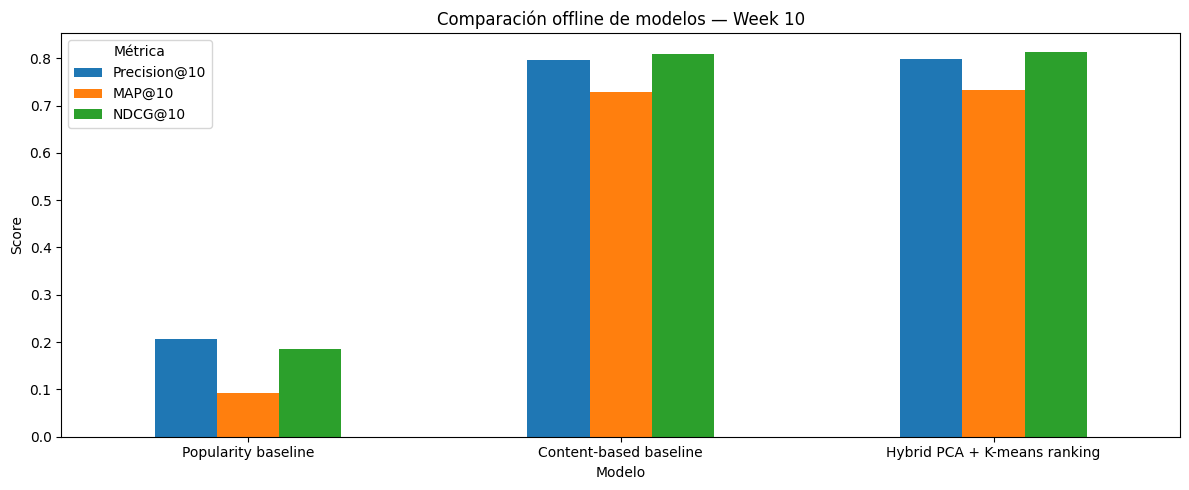

Gráfico guardado en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\reports\W10\w10_metrics_comparison.png


In [17]:
# ============================================================
# Visualización de métricas principales
# ============================================================

plot_df = results_summary.set_index("model")[[f"Precision@{K}", f"MAP@{K}", f"NDCG@{K}"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=0)
ax.set_title("Comparación offline de modelos — Week 10")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.legend(title="Métrica")
plt.tight_layout()

plot_path = REPORT_DIR / "w10_metrics_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", plot_path)

**Insight de evaluación offline.**  
La tabla permite comprobar si el sistema híbrido con PCA + K-means mejora al baseline. Si el híbrido supera al content-based baseline en `MAP@10` o `NDCG@10`, significa que no solo recomienda elementos relevantes, sino que además los ordena mejor en las primeras posiciones. Si el popularity baseline obtiene buena cobertura pero baja precisión, indica que popularidad sola no representa necesariamente similitud temática ni cercanía en el espacio PCA.

# 10.5 Error analysis

En esta sección se revisan dos tipos de casos:

- **Strong cases:** consultas donde el sistema híbrido obtiene alta precisión.
- **Failure cases:** consultas donde el sistema híbrido obtiene baja precisión.

El objetivo no es solo reportar números, sino interpretar por qué el sistema funciona o falla en ciertos repositorios.

In [18]:
# ============================================================
# Identificar casos fuertes y casos fallidos del sistema híbrido
# ============================================================

hybrid_detail = detail_hybrid.copy()
hybrid_detail = hybrid_detail.sort_values([f"Precision@{K}", f"NDCG@{K}"], ascending=False)

strong_cases = hybrid_detail.head(5)
failure_cases = hybrid_detail.tail(5).sort_values([f"Precision@{K}", f"NDCG@{K}"], ascending=True)

print("Strong cases — mejores consultas del sistema híbrido:")
display(strong_cases[["query_repo", "relevant_candidates", f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]])

print("Failure cases — consultas con menor desempeño:")
display(failure_cases[["query_repo", "relevant_candidates", f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]])

Strong cases — mejores consultas del sistema híbrido:


,query_repo,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10
0,keras-team/keras,900,1.0,0.011111,1.0,1.0
1,ageitgey/face_recognition,954,1.0,0.010482,1.0,1.0
5,JaidedAI/EasyOCR,832,1.0,0.012019,1.0,1.0
10,harvard-edge/cs249r_book,506,1.0,0.019763,1.0,1.0
12,AccumulateMore/CV,1086,1.0,0.009208,1.0,1.0


Failure cases — consultas con menor desempeño:


,query_repo,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10
78,EutropicAI/Final2x,127,0.0,0.000000,0.000000,0.000000
403,ruvnet/RuVector,7,0.0,0.000000,0.000000,0.000000
419,yazdotai/graph-networks,17,0.0,0.000000,0.000000,0.000000
329,CloudOrc/SolidUI,81,0.1,0.012346,0.011111,0.066254
87,royshil/obs-backgroundremoval,28,0.1,0.035714,0.012500,0.069431


In [19]:
# ============================================================
# Funciones para explicar casos
# ============================================================

cluster_sizes = df["cluster_kmeans"].value_counts().to_dict()
generic_topics = set([topic for topic, _ in Counter(all_topics).most_common(10)])


def diagnose_query_case(query_idx: int, recommended_indices):
    q_topics = set(df.loc[query_idx, "topics_list"])
    q_eval_topics = set(df.loc[query_idx, "eval_topics"])
    q_cluster = df.loc[query_idx, "cluster_kmeans"]
    cluster_size = cluster_sizes.get(q_cluster, 0)

    shared_counts = [len(shared_topics(query_idx, rec_idx, max_items=100)) for rec_idx in recommended_indices]
    avg_shared = np.mean(shared_counts) if shared_counts else 0
    generic_ratio = len(q_topics.intersection(generic_topics)) / max(len(q_topics), 1)

    possible_causes = []
    if len(q_topics) <= 1:
        possible_causes.append("metadata limitada: el repositorio tiene pocos topics")
    if len(q_eval_topics) == 0:
        possible_causes.append("no tiene topics significativos dentro del vocabulario de evaluación")
    if generic_ratio >= 0.50:
        possible_causes.append("topics demasiado genéricos")
    if cluster_size <= 10:
        possible_causes.append("cluster pequeño, con pocos candidatos cercanos")
    if avg_shared < 1:
        possible_causes.append("bajo solapamiento promedio de topics con los recomendados")
    if not possible_causes:
        possible_causes.append("caso estable: suficiente metadata y candidatos similares")

    return "; ".join(possible_causes)


def explain_case(query_idx: int, top_n: int = 5):
    recs = recommendations_hybrid[query_idx][:top_n]
    query_info = df.loc[[query_idx], ["nombre", "lenguaje", "stars", "cluster_nombre", "topics_list"]].copy()
    query_info["diagnosis"] = diagnose_query_case(query_idx, recs)

    rec_table = df.loc[recs, ["nombre", "lenguaje", "stars", "cluster_nombre"]].copy()
    rec_table.insert(0, "rank", range(1, len(rec_table) + 1))
    rec_table["shared_topics"] = [shared_topics(query_idx, idx) for idx in recs]
    rec_table["same_cluster"] = [int(df.loc[idx, "cluster_kmeans"] == df.loc[query_idx, "cluster_kmeans"]) for idx in recs]
    rec_table["is_relevant"] = [idx in relevance_cache.get(query_idx, set()) for idx in recs]
    return query_info, rec_table

In [20]:
# ============================================================
# Mostrar ejemplos concretos de strong cases y failure cases
# ============================================================

print("Ejemplos de STRONG CASES")
for q_idx in strong_cases["query_idx"].head(2):
    print("\n" + "="*100)
    query_info, rec_table = explain_case(q_idx, top_n=5)
    print("Query:")
    display(query_info)
    print("Top recomendaciones híbridas:")
    display(rec_table)

print("\n\nEjemplos de FAILURE CASES")
for q_idx in failure_cases["query_idx"].head(2):
    print("\n" + "="*100)
    query_info, rec_table = explain_case(q_idx, top_n=5)
    print("Query:")
    display(query_info)
    print("Top recomendaciones híbridas:")
    display(rec_table)

Ejemplos de STRONG CASES

Query:


,nombre,lenguaje,stars,cluster_nombre,topics_list,diagnosis
15,keras-team/keras,Python,64049,Proyectos masivos e influyentes,"[deep-learning, tensorflow, neural-networks, machine-learning, data-science, python, jax, pytorch]",topics demasiado genéricos


Top recomendaciones híbridas:


,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
203,1,CorentinJ/Real-Time-Voice-Cloning,Python,59652,Proyectos masivos e influyentes,"[deep-learning, python, pytorch, tensorflow]",1,True
20,2,deepfakes/faceswap,Python,55195,Proyectos masivos e influyentes,"[deep-learning, machine-learning, neural-networks]",1,True
14,3,scikit-learn/scikit-learn,Python,65953,Proyectos masivos e influyentes,"[data-science, machine-learning, python]",1,True
4,4,rasbt/LLMs-from-scratch,Jupyter Notebook,91729,Proyectos masivos e influyentes,"[deep-learning, machine-learning, neural-networks, python, pytorch]",1,True
0,5,tensorflow/tensorflow,C++,194936,Proyectos masivos e influyentes,"[deep-learning, machine-learning, python, tensorflow]",1,True



Query:


...

,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
879,1,sczhou/CodeFormer,Python,17940,Herramientas de IA modernas,"[pytorch, super-resolution]",1,False
1383,2,huggingface/chat-ui,TypeScript,10683,Herramientas de IA modernas,[typescript],1,False
332,3,ChatLab/ChatLab,TypeScript,6171,Herramientas de IA modernas,"[electron, typescript]",1,False
872,4,xinntao/Real-ESRGAN,Python,35239,Herramientas de IA modernas,"[pytorch, super-resolution]",1,False
955,5,Fanghua-Yu/SUPIR,Python,5524,Herramientas de IA modernas,"[pytorch, super-resolution]",1,False



Query:


,nombre,lenguaje,stars,cluster_nombre,topics_list,diagnosis
2484,ruvnet/RuVector,Rust,3866,Ecosistema LLM emergente,"[ai, ai-ocr, gnn, graph, llm-inference, low-latency, neo4j, ocr, onnx, rust, vector, wasm, attention-mechanism, gnn-...",caso estable: suficiente metadata y candidatos similares


Top recomendaciones híbridas:


,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
1097,1,Michael-A-Kuykendall/shimmy,Rust,4718,Ecosistema LLM emergente,"[llm-inference, rust]",1,False
139,2,tracel-ai/burn,Rust,14966,Ecosistema LLM emergente,"[onnx, rust, wasm]",1,False
1373,3,Zackriya-Solutions/meetily,Rust,11475,Ecosistema LLM emergente,"[ai, rust]",1,False
1417,4,katanemo/plano,Rust,6407,Ecosistema LLM emergente,[llm-inference],1,False
1263,5,rtk-ai/rtk,Rust,38538,Ecosistema LLM emergente,[rust],1,False


In [21]:
# ============================================================
# Guardar tablas de error analysis
# ============================================================

strong_cases_path = ARTIFACT_DIR / "w10_strong_cases.csv"
failure_cases_path = ARTIFACT_DIR / "w10_failure_cases.csv"

strong_cases.to_csv(strong_cases_path, index=False)
failure_cases.to_csv(failure_cases_path, index=False)

print("Strong cases guardados en:", strong_cases_path)
print("Failure cases guardados en:", failure_cases_path)

Strong cases guardados en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_strong_cases.csv
Failure cases guardados en: C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_failure_cases.csv


**Insight de error analysis.**  
Los casos fuertes suelen aparecer cuando el repositorio tiene topics claros y existe un conjunto amplio de candidatos similares. Los casos fallidos aparecen cuando hay pocos topics, topics muy genéricos, clusters pequeños o señales de popularidad que pueden empujar repositorios conocidos pero no necesariamente cercanos al query.

Cuando una recomendación falla, no siempre significa que K-means sea incorrecto; puede indicar que la cercanía en PCA o la popularidad empujaron candidatos que son estructuralmente parecidos, pero no suficientemente relevantes según los topics usados como proxy de evaluación.

# 10.6 Explanation of system type

El sistema desarrollado se define como:

| Tipo de sistema | ¿Aplica? | Justificación |
|---|---:|---|
| Recommendation | Sí | El output es una lista de repositorios sugeridos para un repositorio de consulta. |
| Ranking | Sí | Los candidatos se ordenan de mayor a menor score. |
| Prediction | No como tarea principal | No se predice una variable objetivo supervisada. |
| Segmentation feeding ranking | Sí | El espacio PCA y los clusters K-means alimentan el ranking híbrido como señales adicionales. |

En resumen, el proyecto se formula como un **sistema de recomendación/ranking alimentado por segmentación previa**.

La PCA y los clusters K-means no son el producto final de Week 10, sino entradas para ordenar mejor los candidatos.

# 10.7 Technical expectation

El sistema cumple la expectativa técnica porque define un protocolo de evaluación offline, usa el mismo candidate pool para comparar baseline y modelo híbrido, reporta métricas de ranking y documenta cómo se alinean las features originales, la reducción PCA, los clusters K-means y el score final de recomendación.

Además, el sistema no asume interacciones reales de usuarios. Como el dataset no contiene clicks, ratings o favoritos, la evaluación usa una relevancia proxy basada en topics compartidos.

In [22]:
# ============================================================
# Resumen final de artefactos generados
# ============================================================

print("Artefactos generados para Week 10:")
for path in sorted(ARTIFACT_DIR.glob("*")):
    print("-", path)

print("\nReportes/figuras generadas para Week 10:")
for path in sorted(REPORT_DIR.glob("*")):
    print("-", path)

Artefactos generados para Week 10:
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\repos_with_kmeans_w10.csv
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\repos_with_pca_kmeans_w10.csv
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_failure_cases.csv
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_offline_evaluation_detail.csv
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_offline_evaluation_summary.csv
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\artifacts\W10\w10_strong_cases.csv

Reportes/figuras generadas para Week 10:
- C:\Users\HP\Desktop\Big-data\bd-project\notebooks\reports\W10\w10_metrics_comparison.png
